# EDA — ML-EdgeIIoT-dataset
## Разведывательный анализ данных (IoT Network Intrusion Detection)

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from prettytable import PrettyTable
from collections import Counter

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 110

DATA_PATH = Path("archive/ML-EdgeIIoT-dataset.csv")
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Загружено: {df.shape[0]:,} строк × {df.shape[1]} колонок")
df.head(3)

Загружено: 157,800 строк × 63 колонок


,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
1,6.0,192.168.0.101,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM
2,6.0,192.168.0.152,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,MITM


In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 157800 entries, 0 to 157799
Data columns (total 63 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   frame.time                 157800 non-null  str    
 1   ip.src_host                157800 non-null  str    
 2   ip.dst_host                157800 non-null  str    
 3   arp.dst.proto_ipv4         157800 non-null  str    
 4   arp.opcode                 157800 non-null  float64
 5   arp.hw.size                157800 non-null  float64
 6   arp.src.proto_ipv4         157800 non-null  str    
 7   icmp.checksum              157800 non-null  float64
 8   icmp.seq_le                157800 non-null  float64
 9   icmp.transmit_timestamp    157800 non-null  float64
 10  icmp.unused                157800 non-null  float64
 11  http.file_data             157800 non-null  str    
 12  http.content_length        157800 non-null  float64
 13  http.request.uri.query     157800 non-nu

In [31]:
print(df.isnull().sum().unique())

[0]


In [32]:
pt = PrettyTable(["Столбец", "Тип", "Значение"])

for col in df.columns:
    dtype = str(df[col].dtype)
    if dtype == "str":
        pt.add_row([col, dtype, f"{df[col].nunique()} уник."])
    elif dtype == "float64":
        pt.add_row([col, dtype, f"{df[col].mean():.4f} (среднее)"])

print(pt)

+---------------------------+---------+---------------------------+
|          Столбец          |   Тип   |          Значение         |
+---------------------------+---------+---------------------------+
|         frame.time        |   str   |        155186 уник.       |
|        ip.src_host        |   str   |        19090 уник.        |
|        ip.dst_host        |   str   |         8084 уник.        |
|     arp.dst.proto_ipv4    |   str   |          8 уник.          |
|         arp.opcode        | float64 |      0.0142 (среднее)     |
|        arp.hw.size        | float64 |      0.0598 (среднее)     |
|     arp.src.proto_ipv4    |   str   |          8 уник.          |
|       icmp.checksum       | float64 |    3047.2918 (среднее)    |
|        icmp.seq_le        | float64 |    3239.9798 (среднее)    |
|  icmp.transmit_timestamp  | float64 |    40468.1605 (среднее)   |
|        icmp.unused        | float64 |      0.0000 (среднее)     |
|       http.file_data      |   str   |         

## 3. Распределение классов

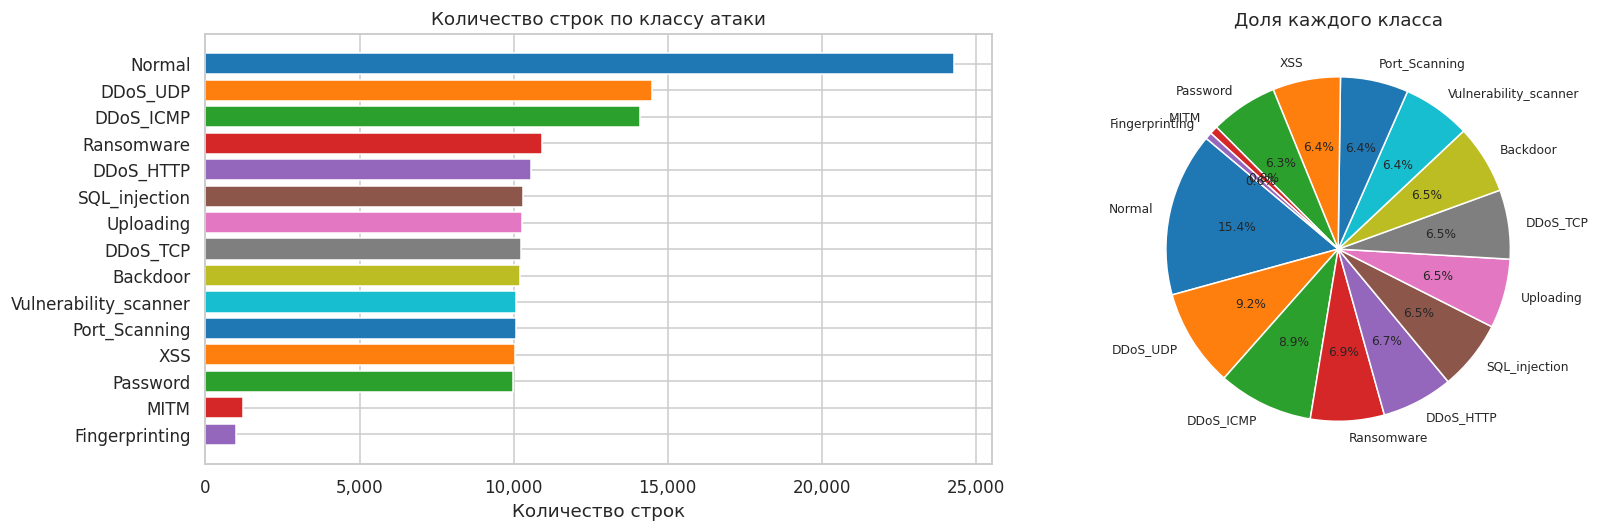

In [33]:
class_counts = df["Attack_type"].value_counts()
class_pct = (class_counts / len(df) * 100).round(2) #процент

# Графики
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = sns.color_palette("tab10", len(class_counts))
axes[0].barh(class_counts.index[::-1], class_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Количество строк")
axes[0].set_title("Количество строк по классу атаки")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", colors=colors, startangle=140,
            textprops={"fontsize": 8})
axes[1].set_title("Доля каждого класса")

plt.tight_layout()
plt.show()

## 4. Статистика числовых признаков

In [34]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовых признаков: {len(num_cols)}")

desc = df[num_cols].describe().T
desc["% нулей"] = (df[num_cols] == 0).mean() * 100
desc["уник. знач."] = df[num_cols].nunique()

pt = PrettyTable(["Признак", "min", "max", "mean", "std", "% нулей", "уник."])
for col, row in desc.iterrows():
    pt.add_row([
        col,
        f"{row['min']:.2f}",
        f"{row['max']:.2f}",
        f"{row['mean']:.3f}",
        f"{row['std']:.3f}",
        f"{row['% нулей']:.1f}%",
        int(row["уник. знач."])
    ])
print(pt)

# Признаки почти постоянные (>99% одно значение)
near_const = [c for c in num_cols if df[c].value_counts(normalize=True).iloc[0] > 0.99]
print(f"\nПочти константных признаков (>99% одно значение): {len(near_const)}")
if near_const:
    pt2 = PrettyTable(["Признак", "Доминирующее значение", "%"])
    for c in near_const:
        top_val = df[c].value_counts(normalize=True)
        pt2.add_row([c, top_val.index[0], f"{top_val.iloc[0]*100:.1f}%"])
    print(pt2)

Числовых признаков: 43
+---------------------------+------+---------------+----------------+----------------+---------+-------+
|          Признак          | min  |      max      |      mean      |      std       | % нулей | уник. |
+---------------------------+------+---------------+----------------+----------------+---------+-------+
|         arp.opcode        | 0.00 |      2.00     |     0.014      |     0.150      |  99.0%  |   3   |
|        arp.hw.size        | 0.00 |      6.00     |     0.060      |     0.596      |  99.0%  |   2   |
|       icmp.checksum       | 0.00 |    65532.00   |    3047.292    |   11144.328    |  90.7%  | 13187 |
|        icmp.seq_le        | 0.00 |    65524.00   |    3239.980    |   11406.073    |  90.1%  | 13824 |
|  icmp.transmit_timestamp  | 0.00 |  77289023.00  |   40468.161    |  1764074.542   |  99.9%  |   84  |
|        icmp.unused        | 0.00 |      0.00     |     0.000      |     0.000      |  100.0% |   1   |
|    http.content_length    | 0.

In [36]:
cols_to_drop = [
    "arp.opcode", "arp.hw.size", "icmp.transmit_timestamp", "icmp.unused",
    "http.tls_port", "udp.port", "udp.time_delta", "dns.qry.qu",
    "dns.qry.type", "dns.retransmission", "dns.retransmit_request",
    "dns.retransmit_request_in", "mqtt.conflag.cleansess", "mqtt.conflags",
    "mqtt.msg_decoded_as", "mqtt.proto_len", "mqtt.topic_len", "mqtt.ver",
    "mbtcp.len", "mbtcp.trans_id", "mbtcp.unit_id"
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Удалено {len(cols_to_drop)} константных колонок. Осталось: {df.shape[1]}")


Удалено 21 константных колонок. Осталось: 42


## 5. Корреляционная матрица

Признаков для корреляции: 22


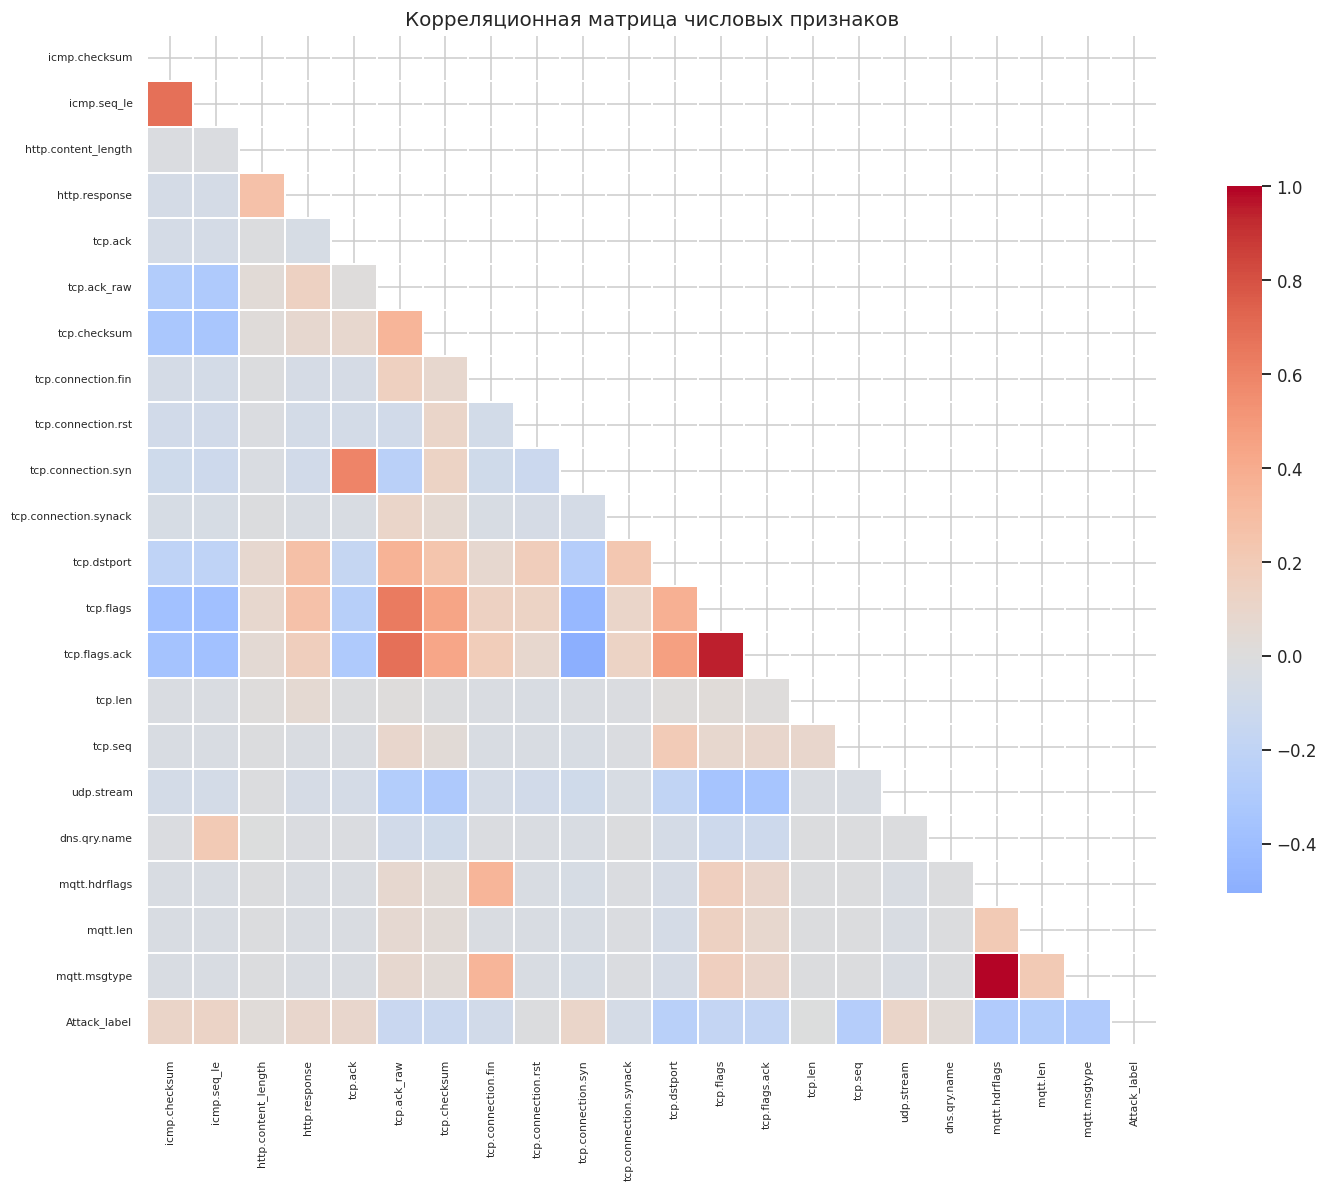


Топ-15 пар с наибольшей корреляцией:
+--------------------+--------------------+------------+
|     Признак 1      |     Признак 2      | Корреляция |
+--------------------+--------------------+------------+
|    mqtt.msgtype    |   mqtt.hdrflags    |   1.0000   |
|   tcp.flags.ack    |     tcp.flags      |   0.9491   |
|    icmp.seq_le     |   icmp.checksum    |   0.6819   |
|   tcp.flags.ack    |    tcp.ack_raw     |   0.6811   |
|     tcp.flags      |    tcp.ack_raw     |   0.6412   |
| tcp.connection.syn |      tcp.ack       |   0.5946   |
|   tcp.flags.ack    | tcp.connection.syn |  -0.5053   |
|   tcp.flags.ack    |    tcp.dstport     |   0.4598   |
|     tcp.flags      |    tcp.checksum    |   0.4430   |
|     tcp.flags      | tcp.connection.syn |  -0.4361   |
|   tcp.flags.ack    |    tcp.checksum    |   0.4313   |
|     tcp.flags      |    icmp.seq_le     |  -0.3845   |
|     tcp.flags      |    tcp.dstport     |   0.3807   |
|   tcp.flags.ack    |    icmp.seq_le     |  -0.37

In [37]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Признаков для корреляции: {len(num_cols)}")

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap="coolwarm", center=0,
            linewidths=0.3, square=True, cbar_kws={"shrink": 0.7},
            xticklabels=True, yticklabels=True)
ax.set_title("Корреляционная матрица числовых признаков", fontsize=13)
ax.tick_params(axis="x", labelsize=7, rotation=90)
ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()

# Топ пар с высокой корреляцией
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["F1", "F2", "corr"]
corr_pairs["abs"] = corr_pairs["corr"].abs()
top_corr = corr_pairs.sort_values("abs", ascending=False).head(15)

pt = PrettyTable(["Признак 1", "Признак 2", "Корреляция"])
for _, row in top_corr.iterrows():
    pt.add_row([row["F1"], row["F2"], f"{row['corr']:.4f}"])
print("\nТоп-15 пар с наибольшей корреляцией:")
print(pt)

In [38]:
cols_to_drop = [
    "mqtt.hdrflags", "tcp.flags.ack", "icmp.checksum"
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Удалено {len(cols_to_drop)} константных колонок. Осталось: {df.shape[1]}")


Удалено 3 константных колонок. Осталось: 39


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Подготовка ---
device = torch.device("cuda")

feature_cols = df.columns[:-2].tolist()  # все кроме Attack_label, Attack_type

def row_to_text(row):
    return ", ".join(f"{col}: {row[col]}" for col in feature_cols)

le = LabelEncoder()
labels = le.fit_transform(df["Attack_type"].to_numpy())
texts = df[feature_cols].apply(row_to_text, axis=1).tolist()

X_train_t, X_temp_t, y_train_l, y_temp_l = train_test_split(texts, labels, test_size=0.3, stratify=labels, random_state=42)
X_val_t, X_test_t, y_val_l, y_test_l   = train_test_split(X_temp_t, y_temp_l, test_size=0.5, stratify=y_temp_l, random_state=42)

print(f"Train: {len(X_train_t)}, Val: {len(X_val_t)}, Test: {len(X_test_t)}")
print(f"Классов: {len(le.classes_)}")

In [ ]:
import gc
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

NUM_CLASSES = len(le.classes_)
BATCH_SIZE  = 32
EPOCHS      = 3
MAX_LEN     = 128

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer):
        self.enc = tokenizer(texts, padding="max_length", truncation=True,
                             max_length=MAX_LEN, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return {k: v[i] for k, v in self.enc.items()}, self.labels[i]

HF_MODELS = [
    ("BERT-tiny",   "google/bert_uncased_L-2_H-128_A-2"),
    ("BERT-mini",   "google/bert_uncased_L-4_H-256_A-4"),
    ("TinyBERT",    "huawei-noah/TinyBERT_General_4L_312D"),
    ("ELECTRA-sm",  "google/electra-small-discriminator"),
    ("MobileBERT",  "google/mobilebert-uncased"),
    ("DistilBERT",  "distilbert-base-uncased"),
    ("DistilGPT-2", "distilgpt2"),
    ("Pythia-70m",  "EleutherAI/pythia-70m"),
]

results = {}

def train_and_eval(name, model_name):
    print(f"\n{'='*60}\n  {name} | {model_name}\n{'='*60}")

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True
    ).to(device)
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.eos_token_id

    train_loader = DataLoader(TextDataset(X_train_t, y_train_l, tokenizer), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TextDataset(X_val_t,   y_val_l,   tokenizer), batch_size=BATCH_SIZE)
    test_loader  = DataLoader(TextDataset(X_test_t,  y_test_l,  tokenizer), batch_size=BATCH_SIZE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for batch, labels_b in train_loader:
            batch    = {k: v.to(device) for k, v in batch.items()}
            labels_b = labels_b.to(device)
            out = model(**batch, labels=labels_b)
            out.loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += out.loss.item()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for batch, labels_b in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                preds.extend(model(**batch).logits.argmax(-1).cpu().tolist())
                trues.extend(labels_b.tolist())

        acc = accuracy_score(trues, preds)
        f1  = f1_score(trues, preds, average="macro")
        print(f"  Epoch {epoch+1}/{EPOCHS} | loss: {total_loss/len(train_loader):.4f} | val acc: {acc:.4f} | val f1: {f1:.4f}")

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for batch, labels_b in test_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            preds.extend(model(**batch).logits.argmax(-1).cpu().tolist())
            trues.extend(labels_b.tolist())

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average="macro")
    print(f"  >> Test acc: {acc:.4f} | F1: {f1:.4f}")

    cm = confusion_matrix(trues, preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Blues", ax=ax)
    ax.set_title(f"{name} | Acc: {acc:.4f} | F1: {f1:.4f}")
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    del model, train_loader, val_loader, test_loader, optimizer
    torch.cuda.empty_cache()
    gc.collect()

    return acc, f1

for name, model_name in HF_MODELS:
    acc, f1 = train_and_eval(name, model_name)
    results[name] = {"acc": acc, "f1": f1}

In [ ]:
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

# Числовые признаки для LSTM/GRU
num_feat_cols = df.select_dtypes(include=[np.number]).columns.difference(["Attack_label"]).tolist()
X_num = df[num_feat_cols].to_numpy(dtype=np.float32)

scaler = StandardScaler()
X_num_train, X_num_temp, yn_train, yn_temp = train_test_split(X_num, labels, test_size=0.3, stratify=labels, random_state=42)
X_num_val, X_num_test, yn_val, yn_test = train_test_split(X_num_temp, yn_temp, test_size=0.5, stratify=yn_temp, random_state=42)

X_num_train = scaler.fit_transform(X_num_train)
X_num_val = scaler.transform(X_num_val)
X_num_test = scaler.transform(X_num_test)

class NumDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # (N, 1, features)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def train_rnn(name, rnn_type):
    INPUT_SIZE  = X_num_train.shape[1]
    HIDDEN_SIZE = 128
    NUM_LAYERS  = 2

    class RNNClassifier(nn.Module):
        def __init__(self):
            super().__init__()
            self.rnn = rnn_type(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, batch_first=True, dropout=0.3)
            self.fc  = nn.Linear(HIDDEN_SIZE, NUM_CLASSES)
        def forward(self, x):
            out, _ = self.rnn(x)
            return self.fc(out[:, -1, :])

    model = RNNClassifier().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    train_loader = DataLoader(NumDataset(X_num_train, yn_train), batch_size=512, shuffle=True)
    val_loader = DataLoader(NumDataset(X_num_val,   yn_val),   batch_size=512)
    test_loader = DataLoader(NumDataset(X_num_test,  yn_test),  batch_size=512)

    print(f"\n{'='*60}\n  {name}\n{'='*60}")
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            loss = loss_fn(model(X_b), y_b)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()

        model.eval()
        preds, trues = [], []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                preds.extend(model(X_b.to(device)).argmax(-1).cpu().tolist())
                trues.extend(y_b.tolist())
        acc = accuracy_score(trues, preds)
        f1 = f1_score(trues, preds, average="macro")
        print(f"  Epoch {epoch+1}/{EPOCHS} | loss: {total_loss/len(train_loader):.4f} | val acc: {acc:.4f} | val f1: {f1:.4f}")

    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds.extend(model(X_b.to(device)).argmax(-1).cpu().tolist())
            trues.extend(y_b.tolist())

    acc = accuracy_score(trues, preds)
    f1  = f1_score(trues, preds, average="macro")
    print(f"  >> Test acc: {acc:.4f} | F1: {f1:.4f}")

    cm = confusion_matrix(trues, preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=le.classes_, yticklabels=le.classes_, cmap="Greens", ax=ax)
    ax.set_title(f"{name} | Acc: {acc:.4f} | F1: {f1:.4f}")
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()
    gc.collect()
    return acc, f1

acc, f1 = train_rnn("LSTM", nn.LSTM)
results["LSTM"] = {"acc": acc, "f1": f1}

acc, f1 = train_rnn("GRU", nn.GRU)
results["GRU"] = {"acc": acc, "f1": f1}

In [ ]:
pt = PrettyTable(["#", "Модель", "Accuracy", "F1 macro", "Победитель"])
sorted_results = sorted(results.items(), key=lambda x: x[1]["f1"], reverse=True)
best_f1 = sorted_results[0][1]["f1"]

for i, (name, m) in enumerate(sorted_results, 1):
    winner = "★" if m["f1"] == best_f1 else ""
    pt.add_row([i, name, f"{m['acc']:.4f}", f"{m['f1']:.4f}", winner])

print("=== Итоговое сравнение моделей ===")
print(pt)

# График
names = [r[0] for r in sorted_results]
accs  = [r[1]["acc"] for r in sorted_results]
f1s   = [r[1]["f1"]  for r in sorted_results]

x = range(len(names))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([i - 0.2 for i in x], accs, width=0.4, label="Accuracy", color="steelblue")
ax.bar([i + 0.2 for i in x], f1s,  width=0.4, label="F1 macro",  color="tomato")
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=30, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Сравнение моделей по Accuracy и F1 macro")
ax.legend()
plt.tight_layout()
plt.show()